In [408]:
# import classy module
from classy import Class

In [409]:
# create instance of the class "Class"
LambdaCDM = Class()
# pass input parameters
# LambdaCDM.set({'omega_b':0.0223828,'omega_cdm':0.1201075,'h':0.67810,'A_s':2.100549e-09,'n_s':0.9660499,'tau_reio':0.05430842})
LambdaCDM.set({'omega_b':0.02237,'omega_cdm':0.1200,'h':0.6736,'A_s':2.0830e-9,'n_s':0.9649,'tau_reio':0.0568, 'k_pivot': 0.05, 'N_ur':3.046, 'T_cmb': 2.7255})
LambdaCDM.set({'output':'mPk','lensing':'no','P_k_max_1/Mpc':3.0, 'z_max_pk': 1.0})

# run class
LambdaCDM.compute()

# get reduced Hubble for conversions to 1/Mpc
h = LambdaCDM.h()
print(h)

0.6736


In [410]:
n1, n2, n3 = 4, 4, 4

def f_idx(n1, n2, n3, nu_list, count, case):

    if (n1<=0 or n2<=0 or n3<=0):
        #print(f"case {case}:", nu_list)
        return nu_list, count
    elif n1 > 1:
        nu1 = n1 - 1
        nu2 = n2
        nu3 = n3
    elif n2 > 1:
        nu1 = n1
        nu2 = n2 - 1 
        nu3 = n3
    elif n3 > 1:
        nu1 = n1
        nu2 = n2
        nu3 = n3 - 1
    else:
        #print(f"case {case}:", nu_list)
        return nu_list, count
    
    if not [nu1, nu2, nu3] in nu_list:
        nu_list.append([nu1, nu2, nu3])

    count += 1

    if case==1:
        return f_idx(nu1, nu2, nu3, nu_list, count, case)
    if case==2:
        return f_idx(nu1, nu2-1, nu3+1, nu_list, count, case)
    if case==3:
        return f_idx(nu1, nu2+1, nu3-1, nu_list, count, case)
    if case==4:
        return f_idx(nu1-1, nu2, nu3+1, nu_list, count, case)
    if case==5:
        return f_idx(nu1+1, nu2, nu3-1, nu_list, count, case)
    if case==6:
        return f_idx(nu1-1, nu2+1, nu3, nu_list, count, case)
    if case==7:
        return f_idx(nu1+1, nu2-1, nu3, nu_list, count, case)

lst = []
count = 0
lst, count = f_idx(n1, n2, n3, lst, count, 1)
lst, count = f_idx(n1, n2, n3, lst, count, 2)
lst, count = f_idx(n1, n2, n3, lst, count, 3)
lst, count = f_idx(n1, n2, n3, lst, count, 4)
lst, count = f_idx(n1, n2, n3, lst, count, 5)
lst, count = f_idx(n1, n2, n3, lst, count, 6)
lst, count = f_idx(n1, n2, n3, lst, count, 7)



#print(nu1, nu2, nu3)
#print(nu1, nu2-1, nu3+1)
#print(nu1, nu2+1, nu3-1)
#print(nu1-1, nu2, nu3+1)
#print(nu1+1, nu2, nu3-1)
#print(nu1-1, nu2+1, nu3)
#print(nu1+1, nu2-1, nu3)



In [411]:
# uncomment to get plots displayed in notebook
%matplotlib inline
import matplotlib.pyplot as plt
from math import pi
from matplotlib import rc
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec
import numpy as np

import pandas as pd


# Mathematica directory
dir = "/Users/fynn/Desktop/Uni/Master/Masters-thesis/04 Mathematica"

# Enable LaTeX rendering
rcParams['figure.dpi'] = 120
rc('text', usetex=False)
rc('font', family='serif', size=15)

rcParams.update({
    'font.size': 15,
    'axes.titlesize': 15,
    'axes.labelsize': 15,
    'xtick.labelsize': 15,
    'ytick.labelsize': 15,
    'legend.fontsize': 15,
})

def compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel):
    factor_real = np.mean(y1real/y2real)
    factor_imag = np.mean(y1imag/y2imag)
    print("factor=", factor_real, factor_imag)


    residuals_real = 100 * (y1real-y2real)/y1real
    residuals_imag = 100 * (y1imag-y2imag)/y1imag

    fig = plt.figure(figsize=(8, 6))
    gs = GridSpec(2, 1, height_ratios=[3, 1], hspace=0.1)

    # Main plot (data + fit)
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(x1, np.abs(y1real), label="real analytical")
    ax1.plot(x2, np.abs(y2real), ls="--", label="real mathematica numerical")
    ax1.plot(x1, np.abs(y1imag), label="imag analytical")
    ax1.plot(x2, np.abs(y2imag), ls="--", label="imag mathematica numerical")
    ax1.set_yscale("log")
    ax1.set_title(rf"{ylabel}")
    ax1.legend()
    ax1.grid()
    ax1.tick_params(labelbottom=False)  # Hide x-axis labels for top plot

    # Residual plot (same x-axis)
    ax2 = fig.add_subplot(gs[1], sharex=ax1)  # Shares x-axis with ax1
    ax2.axhline(0, color='black', linestyle='--', linewidth=1)
    ax2.plot(x1, (residuals_real), color='black', label="Residuals Real")
    ax2.plot(x1, (residuals_imag), color='black', label="Residuals Imag")
    ax2.set_xlabel(rf"k $\left[h/\mathrm{{Mpc}}\right]$")
    ax2.set_ylabel(r"Res. $\%$")
    ax2.set_xscale("log")
    ax2.legend()
    ax2.grid()

# Define function to compare Mathematica to CLASS:

In [412]:
def chi2(y1, y2, idxs):
    N = len(y1)
    chi = np.sqrt(np.sum((y1/y2-1)**2)/N)
    if 1e-4<chi<0.1:
        print(f"\n\nWarning: Deviation between mathematica and CLASS: {idxs}: chi = {chi}")
        return chi, 0
    elif chi>0.1:
        print(f"\n\nError: Large Deviation between mathematica and CLASS: {idxs}: chi = {chi}")
        if len(y1)>1:
            x = np.arange(len(y1))
            print(y1)
            plt.plot(x, np.abs(y1))
            plt.plot(x, np.abs(y2))
            plt.yscale("log")
            plt.show()
        return chi, 0

    return chi, 1

In [413]:
k2_peak_n = np.array([0., -3.4e-2, -1e-3, -7.6e-5, -1.56e-5, -3.4e-2, -1e-3, -7.6e-5, -1.56e-5, 0.])*h**2
k2_UV_n = np.array([1e-4, 6.9e-2, 8.2e-3, 1.3e-3, 1.35e-5, -6.9e-2, -8.2e-3, -1.3e-3, -1.35e-5, 0.])*h**2 # original 

M_n = -k2_peak_n + 1j*k2_UV_n
M_n[0] = 1e-4 + 1j*0.



In [414]:
k_size = 50
z_size = 1
mu_size= 1

k_min = 1e-3
k_max = 1e-1

k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)*h
k_input = k.reshape((k_size, z_size, mu_size)) # need to reshape to also habe z and mu dependence
z = np.linspace(0, 1, z_size)


# $B_{master}$

3200
counter 0 0
factor= 0.999999999887699 1.0000000011541044


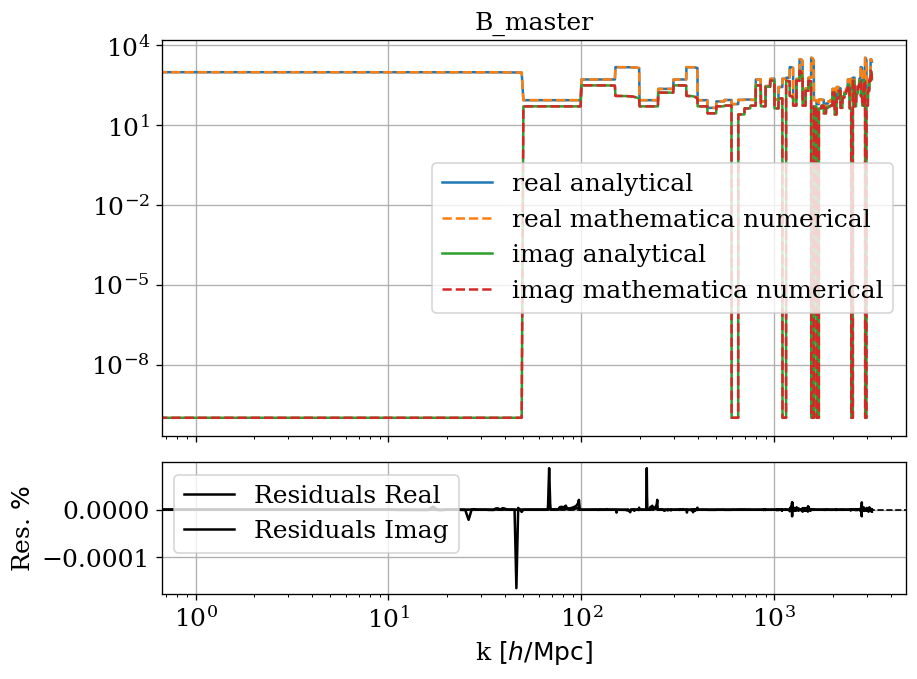

In [415]:
B_master_arr = np.zeros(k_size, dtype=complex)

M1_idx = 2
M2_idx = 8

# Fill the array using the CLASS implementation
#for idx, k_in in enumerate(k):
#    B_master_arr[idx] = LambdaCDM.get_B_master(k_in**2, M_n[M1_idx], M_n[M2_idx])

# read Mathematica file
B_master_mathematica = np.array(pd.read_csv(dir+"/B_master_integral/B_master_mathematica_mutliindex.csv", names=["k", "M1", "M2", "Real", "Imag"]))

M1_arr = B_master_mathematica[:,0]
M2_arr = B_master_mathematica[:,1]
k_math = B_master_mathematica[:,2]
B_math_real = B_master_mathematica[:,3]
B_math_imag = B_master_mathematica[:,4]

k_len = len(k_math)
M1_len = len(M1_arr)
M2_len = len(M2_arr)
print(k_len)

B_master_arr = np.zeros(k_len, dtype=complex)
x = np.arange(k_len)

for idx in range(k_len):
    k_in = k_math[idx]
    M1_idx = int(M1_arr[idx])
    M2_idx = int(M2_arr[idx])
    B_master_arr[idx] = LambdaCDM.get_B_master(k_in**2, M_n[M1_idx], M_n[M2_idx])


#x1 = k/h
x2 = k_math/h
y1real = B_master_arr.real
y1imag = B_master_arr.imag + 1e-10
y2real = B_math_real 
y2imag = B_math_imag + 1e-10
ylabel = "B_master"

chireal = np.abs(y1real/y2real-1)
chiimag = np.abs(y1imag/y2imag-1)

val = 0.0025
real_count = 0
imag_count = 0
for i in range(len(chiimag)):
    if chireal[i]>val:
        real_count += 1
        print("real", M1_arr[i], M2_arr[i])
    if chiimag[i]>val:
        imag_count += 1
        print("imag", M1_arr[i], M2_arr[i])

print("counter", real_count, imag_count)
compare_integrals(x, x, y1real, y1imag, y2real, y2imag, ylabel)

# $\text{Tad}_\text{master}$

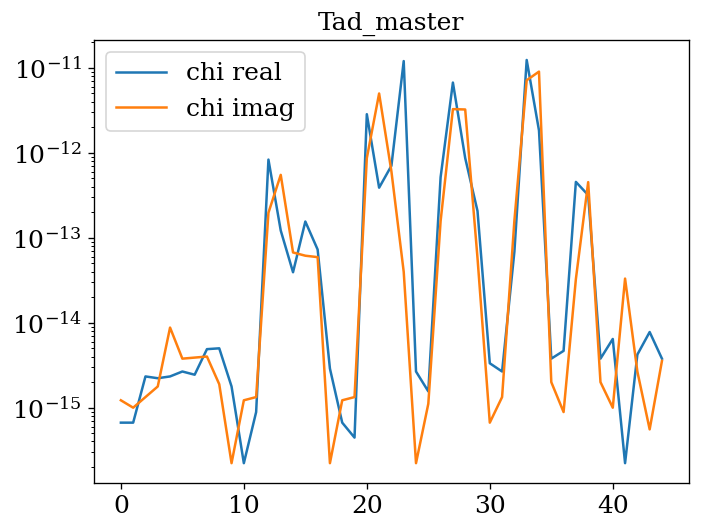

In [416]:
M_idx   = 4


# read Mathematica file
Tad_master_mathematica = np.array(pd.read_csv(dir+f"/Tad_master_integral/Tad_master_mathematica_mutliindex.csv", names=["n", "d", "Real", "Imag"]))
n_arr = Tad_master_mathematica[:,0]
d_arr = Tad_master_mathematica[:,1]
Tad_math_real = Tad_master_mathematica[:,2]
Tad_math_imag = Tad_master_mathematica[:,3]


idx_len = len(n_arr)
Tad_master_arr = np.zeros(idx_len, dtype=complex)

for idx in range(idx_len):
    n = int(n_arr[idx])
    d = int(d_arr[idx])
    Tad_master_arr[idx] = LambdaCDM.get_Tad_master(n, d, M_n[M_idx])


y2real = Tad_math_real
y2imag = Tad_math_imag
y1real = Tad_master_arr.real
y1imag = Tad_master_arr.imag

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)

x = np.arange(idx_len)
plt.plot(x, chi_real, label="chi real")
plt.plot(x, chi_imag, label="chi imag")
plt.yscale("log")
plt.legend()
plt.title("Tad_master")
plt.show()


# $T_\text{master}$

factor= 1.1901863056101372 0.8984314676634609


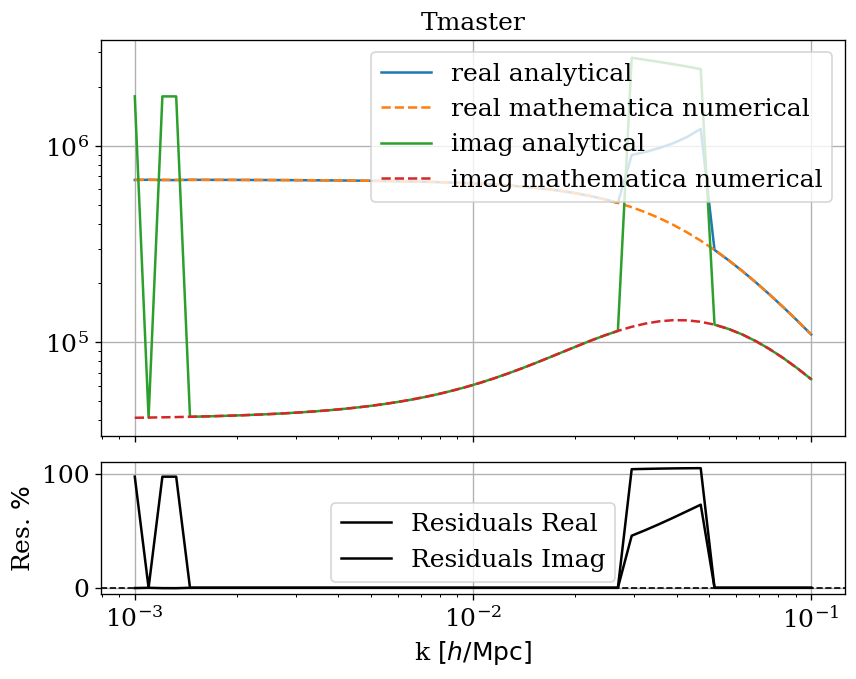

In [417]:
k_min = 1e-3
k_max = 1e-1
k_size = 50
k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)*h

M1_idx = 7
M2_idx = 3
M3_idx = 4

k1val = 0.015
cos12 = 0.1

Tmaster_arr = np.zeros(k_size, dtype=complex)
# Fill the array using the CLASS implementation
for idx, k2_in in enumerate(k):
    #k1val = k2_in
    k3_in_sq = k1val**2 + k2_in**2 + 2*k1val*k2_in*cos12
    Tmaster_arr[idx] = LambdaCDM.get_T_master(k2_in**2, k1val**2, k3_in_sq, M_n[M1_idx], M_n[M2_idx], M_n[M3_idx])

# read Mathematica file
Tmaster_mathematica = np.array(pd.read_csv(dir+"/T_master_integral/T_master_mathematica.csv", names=["k", "Real", "Imag"]))
k_math = Tmaster_mathematica[:,0]
Tmaster_math_real = Tmaster_mathematica[:,1]
Tmaster_math_imag = Tmaster_mathematica[:,2]


x1 = k/h
x2 = k_math/h
y1real = Tmaster_arr.real + 1.e-8
y1imag = Tmaster_arr.imag + 1.e-8
y2real = Tmaster_math_real + 1.e-8
y2imag = Tmaster_math_imag + 1.e-8
ylabel = "Tmaster"


compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel)

In [418]:
# util_antideriv
from testtest import Antideriv, Prefactor, Fint, TriaMaster
from gmpy2 import atan, log, sqrt, gamma

CHOP_TOL = 1.e-13
x = 1.
a = -1/9.
y1 = 2.e-3 + 1j*0.
y2 = 4.42e-2 + 1j*0.
x0 = 1.4 + 1j*0.

aa=-0.0001
y1=-12.+32.0*1j
y2=0.+0.0*1j
CHOP_TOL=1e-08

#out_antideriv_CLASS = LambdaCDM.get_util_antideriv(x, y1, y2, x0)
out_prefactor_CLASS = LambdaCDM.get_util_prefactor(aa, y1, y2)
#out_antideriv_Babis = Antideriv(x, y1, y2, x0, CHOP_TOL)
out_prefactor_Babis = Prefactor(aa, y1, y2, CHOP_TOL)

#LambdaCDM.get_util_F_int(a, y1, y2, x0)
#fint = Fint(a, y1, y2, x0, CHOP_TOL)

M1_idx = 0
M2_idx = 3
M3_idx = 3

k1 = 1.e-2
k2 = 3.62e-2
k3 = 1.e-3

#T_master = LambdaCDM.get_T_master(k1**2, k2**2, k3**2, M_n[M1_idx], M_n[M2_idx], M_n[M3_idx])
#T_master2 = TriaMaster(k1**2, k2**2, k3**2, M_n[M1_idx], M_n[M2_idx], M_n[M3_idx], CHOP_TOL)

#print("T_master = ",T_master)
#print("T_master = ",T_master2)
print("prefactor = ",out_prefactor_CLASS)
print("prefactor = ",out_prefactor_Babis)

M1 = M_n[M1_idx]
M2 = M_n[M2_idx]
M3 = M_n[M3_idx]

k12 = k1**2
k22 = k2**2
k32 = k3**2

k14 = k12**2
k24 = k22**2
k34 = k32**2

y = 1

R2 = -k12*y+k32*y-k32
R1 = -M2*y+M3*y+k12*y-k32*y+M1-M3+k32
R0 = M2*y-M3*y+M3


S2 = -k14+2.*k12*k22+2.*k12*k32-k24+2.*k22*k32-k34
S1 =-4.*M1*k22-2.*M2*k12+2.*M2*k22+2.*M2*k32+2.*M3*k12+2.*M3*k22-2.*M3*k32-2.*k12*k22+2.*k24-2.*k22*k32
S0 =-M2*M2+2.*M2*M3-2.*M2*k22-M3*M3-2.*M3*k22-k24

DiscR_sqrt = sqrt(R1*R1 - 4.*R2*R0)
DiscS_sqrt = sqrt(S1*S1 - 4.*S2*S0)

solS1 = (-S1+DiscS_sqrt)/2./S2;				# x_+
solS2 = (-S1-DiscS_sqrt)/2./S2;  			# x_-

solR1 = ((-R1+DiscR_sqrt)/2.)/R2;     		# z_+
solR2 = ((-R1-DiscR_sqrt)/2.)/R2; 			# z_-

print(f"solS1, = {solS1}, solS2, = {solS2}, solR1, = {solR1}, solR2, = {solR2}")

prefactor =  (-3.86576670987389e-15-99.99999999999999j)
prefactor =  -5.0183775213613528e-15-99.999999999999986j
solS1, = 0.937199+2.274742j, solS2, = 0.995572-0.160402j, solR1, = 0.644349-5.724566j, solR2, = 1.010811-0.174014j


factor= 0.9904314370125002 1.2873615500357258
Real: M1 = 7.0, M2 = 8.0, M3 = 3.0, k1 = 0.06736, k2 = 0.006736, CLASS = 542.8578472116855
Imag: M1 = 7.0, M2 = 8.0, M3 = 3.0, k1 = 0.06736, k2 = 0.006736, CLASS = 3059.722474356355
Real: M1 = 7.0, M2 = 4.0, M3 = 3.0, k1 = 0.06736, k2 = 0.006736, CLASS = 672.6295186015935
Imag: M1 = 7.0, M2 = 4.0, M3 = 3.0, k1 = 0.06736, k2 = 0.006736, CLASS = 2964.6804561305526
Real: M1 = 7.0, M2 = 0.0, M3 = 3.0, k1 = 0.06736, k2 = 0.006736, CLASS = 232.7895778229438
Imag: M1 = 7.0, M2 = 0.0, M3 = 3.0, k1 = 0.06736, k2 = 0.006736, CLASS = 5555.845360495474
Real: M1 = 7.0, M2 = 3.0, M3 = 8.0, k1 = 0.06736, k2 = 0.006736, CLASS = 370.3087187075544
Imag: M1 = 7.0, M2 = 3.0, M3 = 8.0, k1 = 0.06736, k2 = 0.006736, CLASS = 2865.305602494952
Real: M1 = 7.0, M2 = 3.0, M3 = 4.0, k1 = 0.06736, k2 = 0.006736, CLASS = 451.98967419359013
Imag: M1 = 7.0, M2 = 3.0, M3 = 4.0, k1 = 0.06736, k2 = 0.006736, CLASS = 2783.348152933015
Real: M1 = 7.0, M2 = 3.0, M3 = 0.0, k1 = 0

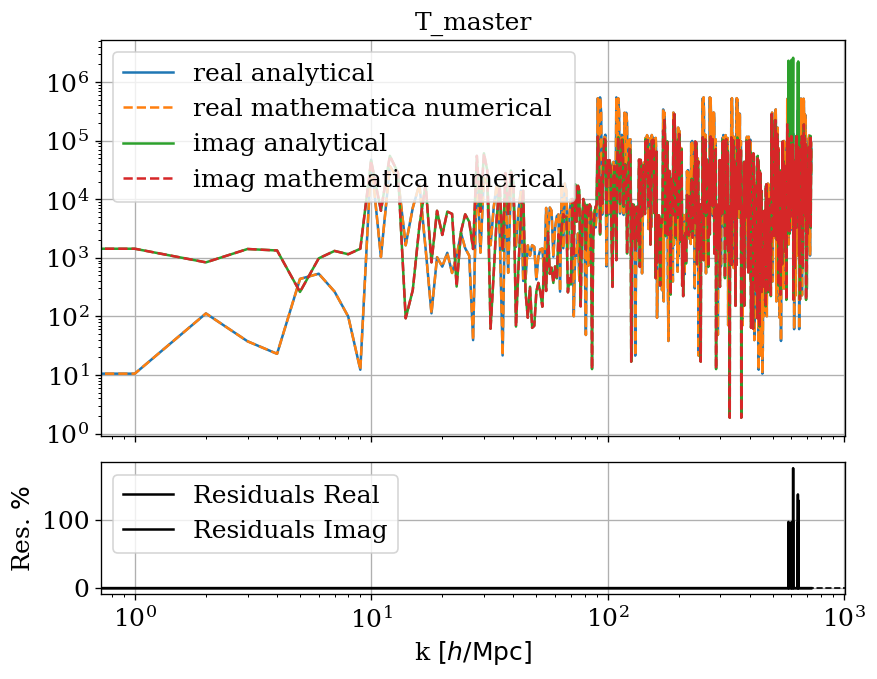

In [419]:
T_master_arr = np.zeros(k_size, dtype=complex)

cos12 = 0.1

# Fill the array using the CLASS implementation
#for idx, k_in in enumerate(k):
#    B_master_arr[idx] = LambdaCDM.get_B_master(k_in**2, M_n[M1_idx], M_n[M2_idx])

# read Mathematica file
T_master_mathematica = np.array(pd.read_csv(dir+"/T_master_integral/T_master_mathematica_mutliindex.csv", names=["M1", "M2", "M3", "k1", "k2", "Real", "Imag"]))

M1_arr = T_master_mathematica[:,0]
M2_arr = T_master_mathematica[:,1]
M3_arr = T_master_mathematica[:,2]
k1_math = T_master_mathematica[:,3]
k2_math = T_master_mathematica[:,4]
T_math_real = T_master_mathematica[:,5]
T_math_imag = T_master_mathematica[:,6]
if isinstance(T_math_imag[0], str):
    for idx, temp in enumerate(T_math_imag):
        T_math_imag[idx] =  eval(temp.replace("*^", "**"))


k_len = len(k1_math)
M1_len = len(M1_arr)
M2_len = len(M2_arr)
M3_len = len(M3_arr)

T_master_arr = np.zeros(k_len, dtype=complex)
x = np.arange(k_len)

for idx in range(k_len):
    k1_in = k1_math[idx]
    k2_in = k2_math[idx]
    k3_in_sq = k1_in**2 + k2_in**2 + 2*k1_in*k2_in*cos12
    M1_idx = int(M1_arr[idx])
    M2_idx = int(M2_arr[idx])
    M3_idx = int(M3_arr[idx])
    T_master_arr[idx] = LambdaCDM.get_T_master(k1_in**2, k2_in**2, k3_in_sq, M_n[M1_idx], M_n[M2_idx], M_n[M3_idx])
    #T_master_arr[idx] = TriaMaster(k1_in**2, k2_in**2, k3_in_sq, M_n[M1_idx], M_n[M2_idx], M_n[M3_idx], CHOP_TOL)


#x1 = k/h
x2 = k_math/h
y1real = T_master_arr.real + 1.e-8
y1imag = T_master_arr.imag + 1.e-8
y2real = T_math_real + 1.e-8
y2imag = T_math_imag + 1.e-8
ylabel = "T_master"

y1real = np.array(y1real)
y1imag = np.array(y1imag)
y2real = np.array(y2real)
y2imag = np.array(y2imag)
ylabel = np.array(ylabel)

cut = 1.

mask = np.abs(y1imag/y2imag-1) < cut
#mask = (M1_arr == 0) & (M2_arr == 0) & (M3_arr == 0)



compare_integrals(x, x, y1real, y1imag, y2real, y2imag, ylabel)

counter = 0
for idx in range(k_len):
    if np.abs(y1real[idx]/y2real[idx]-1)>cut:
        counter += 1
        print(f"Real: M1 = {M1_arr[idx]}, M2 = {M2_arr[idx]}, M3 = {M3_arr[idx]}, k1 = {k1_math[idx]}, k2 = {k2_math[idx]}, CLASS = {np.abs(y1real[idx]/y2real[idx]-1)*100}")
    if np.abs(y1imag[idx]/y2imag[idx]-1)>cut:
        counter += 1
        print(f"Imag: M1 = {M1_arr[idx]}, M2 = {M2_arr[idx]}, M3 = {M3_arr[idx]}, k1 = {k1_math[idx]}, k2 = {k2_math[idx]}, CLASS = {np.abs(y1imag[idx]/y2imag[idx]-1)*100}")

print(f"counter = {counter}")

# $\text{Tad}_\text{var}$

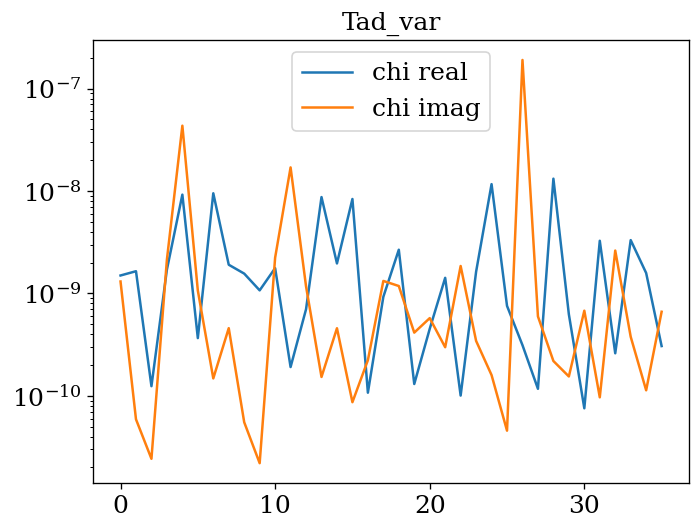

In [420]:
M_idx   = 4
k_in    = 3.14*1e-2*h

# read Mathematica file
Tad_var_mathematica = np.array(pd.read_csv(dir+f"/Tad_var_integral/Tad_var_mathematica_mutliindex.csv", names=["n", "d", "Real", "Imag"]))
n_arr = Tad_var_mathematica[:,0]
d_arr = Tad_var_mathematica[:,1]
Tad_math_real = Tad_var_mathematica[:,2]
Tad_math_imag = Tad_var_mathematica[:,3]


idx_len = len(n_arr)
Tad_var_arr = np.zeros(idx_len, dtype=complex)

for idx in range(idx_len):
    n = int(n_arr[idx])
    d = int(d_arr[idx])
    Tad_var_arr[idx] = LambdaCDM.get_Tad_var(n, d, k_in**2, M_n[M_idx])


y2real = Tad_math_real
y2imag = Tad_math_imag
y1real = Tad_var_arr.real
y1imag = Tad_var_arr.imag

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)

x = np.arange(idx_len)
plt.plot(x, chi_real, label="chi real")
plt.plot(x, chi_imag, label="chi imag")
plt.yscale("log")
plt.legend()
plt.title("Tad_var")
plt.show()

# massive_num

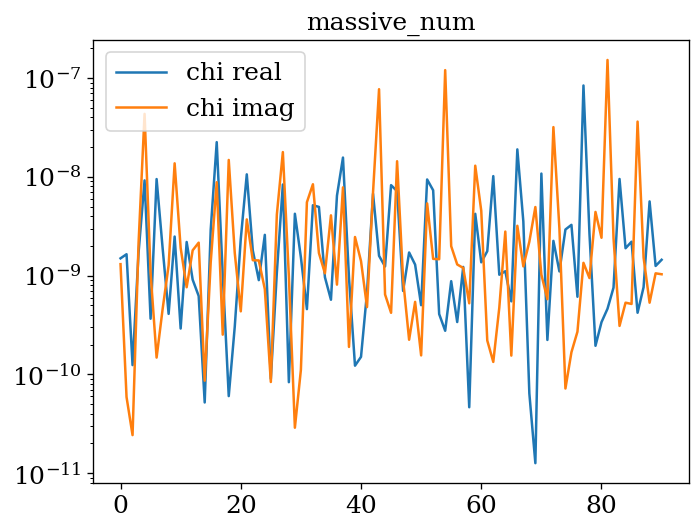

In [421]:
M1_idx = 2
M2_idx = 4
k_in = 5.e-3*h

# read Mathematica file
massive_num_mathematica = np.array(pd.read_csv(dir+"/massive_num_integral/massive_num_mathematica_multiindex.csv", names=["n", "d", "Real", "Imag"]))
n_arr = massive_num_mathematica[:,0]
d_arr = massive_num_mathematica[:,1]
massive_num_math_real = massive_num_mathematica[:,2]
massive_num_math_imag = massive_num_mathematica[:,3]

idx_len = len(n_arr)
massive_num_arr = np.zeros(idx_len, dtype=complex)
for idx in range(idx_len):
    n = n_arr[idx]
    d = d_arr[idx]
    massive_num_arr[idx] = LambdaCDM.get_massive_num(n, d, k_in**2, M_n[M1_idx], M_n[M2_idx])


y1real = massive_num_arr.real+1e-10
y1imag = massive_num_arr.imag+1e-10
y2real = massive_num_math_real+1e-10
y2imag = massive_num_math_imag+1e-10

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)


x = np.arange(idx_len)
plt.plot(x, chi_real, label="chi real")
plt.plot(x, chi_imag, label="chi imag")
plt.yscale("log")
plt.legend()
plt.title("massive_num")
plt.show()

# L_recursion

factor= -6094693.981001606 -949124.0280158573


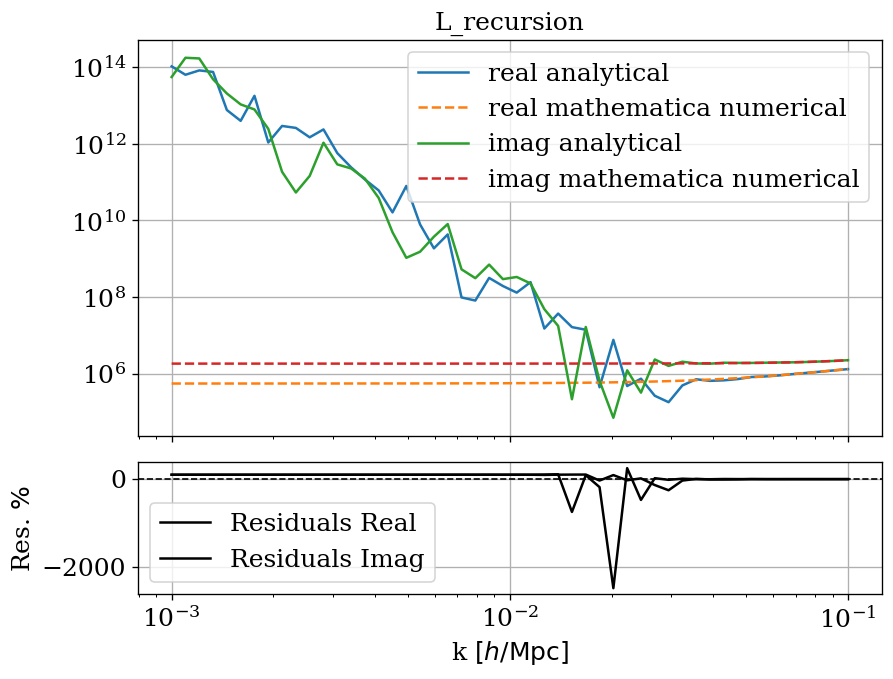

In [422]:
k_min = 1e-3
k_max = 1e-1
k_size = 50
k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)*h

M1_idx = 1
M2_idx = 1
M3_idx = 4

n1 = 1
n2 = 1
n3 = 1
d1 = 3
d2 = 3
d3 = 3

k1val = 0.001
cos12 = 0.1

Lrecursion_arr = np.zeros(k_size, dtype=complex)
# Fill the array using the CLASS implementation
for idx, k2_in in enumerate(k):
    #k1val = k2_in
    k3_in_sq = k1val**2 + k2_in**2 + 2*k1val*k2_in*cos12
    Lrecursion_arr[idx] = LambdaCDM.get_L_recursion(n1, d1, n2, d2, n3, d3, k2_in**2, k1val**2, k3_in_sq, M_n[M1_idx], M_n[M2_idx], M_n[M3_idx])

# read Mathematica file
Lrecursion_mathematica = np.array(pd.read_csv(dir+"/L_recursion_integral/L_recursion_mathematica.csv", names=["k", "Real", "Imag"]))
k_math = Lrecursion_mathematica[:,0]
Lrecursion_math_real = Lrecursion_mathematica[:,1]
Lrecursion_math_imag = Lrecursion_mathematica[:,2]


x1 = k/h
x2 = k_math/h
y1real = Lrecursion_arr.real + 1.e-8
y1imag = Lrecursion_arr.imag + 1.e-8
y2real = Lrecursion_math_real + 1.e-8
y2imag = Lrecursion_math_imag + 1.e-8
ylabel = "L_recursion"


compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel)

39 35 168
1.0 1.0 1.0 2.0 3.0 3.0 70.69606014334786 188.97706231212132
1.0 1.0 1.0 3.0 3.0 3.0 3675.9170693631495 2523.063859751762
1.0 1.0 2.0 1.0 3.0 3.0 18.38256233347012 0.2601346850427605
1.0 1.0 2.0 2.0 3.0 3.0 82.1253524060147 15.260295751859537
1.0 1.0 2.0 3.0 3.0 1.0 11.000046273361212 0.3226978091642352
1.0 1.0 2.0 3.0 3.0 3.0 2722.1930237446663 221.33050963105524
1.0 1.0 3.0 2.0 3.0 3.0 121.02741647505745 18.133169736299898
1.0 1.0 3.0 3.0 3.0 2.0 13.823235573168343 0.4066595579396428
1.0 1.0 3.0 3.0 3.0 3.0 507.24829118790495 2111.2910549080875
1.0 2.0 1.0 1.0 3.0 3.0 20.07628673081427 0.26088913884178133
1.0 2.0 1.0 2.0 3.0 3.0 81.7686448386626 15.432061449660306
1.0 2.0 1.0 3.0 3.0 3.0 2752.9093145166103 211.7447657049565
1.0 2.0 2.0 2.0 3.0 3.0 111.18803261888374 18.079435354834562
1.0 2.0 2.0 3.0 3.0 3.0 495.0111298411783 2231.2480037701935
1.0 2.0 3.0 3.0 3.0 3.0 1257.5480060568736 177.46270458575304
1.0 3.0 1.0 2.0 3.0 3.0 102.9087831721913 18.024742002654037
1.0 3.0 

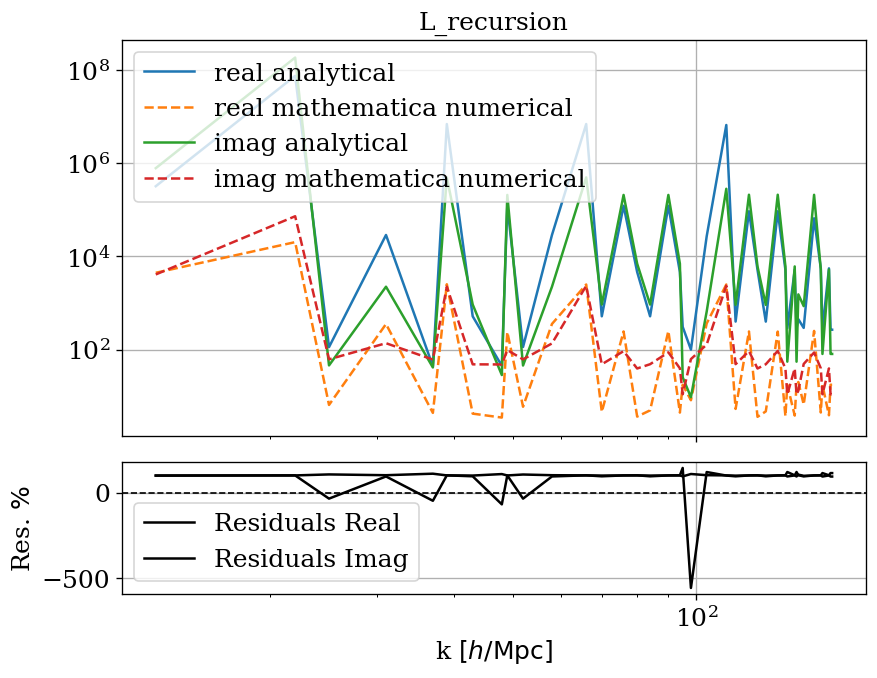

In [423]:
# read Mathematica file
L_recursion_mathematica = np.array(pd.read_csv(dir+"/L_recursion_integral/L_recursion_mathematica_mutliindex.csv", names=["M1", "M2", "M3", "k1", "k2", "k3", "n1", "n2", "n3", "d1", "d2", "d3", "Real", "Imag"]))

M1_arr = L_recursion_mathematica[:,0]
M2_arr = L_recursion_mathematica[:,1]
M3_arr = L_recursion_mathematica[:,2]
k1_math = L_recursion_mathematica[:,3]
k2_math = L_recursion_mathematica[:,4]
k3_math = L_recursion_mathematica[:,5]
n1_math = L_recursion_mathematica[:,6]
n2_math = L_recursion_mathematica[:,7]
n3_math = L_recursion_mathematica[:,8]
d1_math = L_recursion_mathematica[:,9]
d2_math = L_recursion_mathematica[:,10]
d3_math = L_recursion_mathematica[:,11]
L_recursion_math_real = L_recursion_mathematica[:,12]
L_recursion_math_imag = L_recursion_mathematica[:,13]


k_len = len(k1_math)


L_recursion_arr = np.zeros(k_len, dtype=complex)
x = np.arange(k_len)

for idx in range(k_len):
    n1 = n1_math[idx]
    n2 = n2_math[idx]
    n3 = n3_math[idx]
    d1 = d1_math[idx]
    d2 = d2_math[idx]
    d3 = d3_math[idx]
    #print(n1, n2, n3, d1, d2, d3)
    if d1+d2+d3<1+n1+n2+n3:
        print("divergent case")
        break
    k1_in = k1_math[idx]
    k2_in = k2_math[idx]
    k3_in = k3_math[idx]
    M1_idx = int(M1_arr[idx])
    M2_idx = int(M2_arr[idx])
    M3_idx = int(M3_arr[idx])
    #print(d1, d2, d3, k1_in, k2_in, k3_in, M1_idx, M2_idx, M3_idx)
    L_recursion_arr[idx] = LambdaCDM.get_L_recursion(n1, d1, n2, d2, n3, d3, k1_in**2, k2_in**2, k3_in**2, M_n[M1_idx], M_n[M2_idx], M_n[M3_idx])



#x1 = k/h
x2 = k_math/h
y1real = L_recursion_arr.real + 1.e-8
y1imag = L_recursion_arr.imag + 1.e-8
y2real = L_recursion_math_real + 1.e-8
y2imag = L_recursion_math_imag + 1.e-8
ylabel = "L_recursion"

y1real = np.array(y1real)
y1imag = np.array(y1imag)
y2real = np.array(y2real)
y2imag = np.array(y2imag)
ylabel = np.array(ylabel)

cut = 1.
chi_real = np.abs(y1real/y2real-1)
chi_imag = np.abs(y1imag/y2imag-1)
mask_real = chi_real > 5.
mask_imag = chi_imag > 5.
mask = mask_real
#mask = (M1_arr == 0) & (M2_arr == 0) & (M3_arr == 0)

print(np.sum(mask_real),np.sum(mask_imag),k_len)
for i in range(np.sum(mask)):
    print(n1_math[mask][i], n2_math[mask][i], n3_math[mask][i], d1_math[mask][i], d2_math[mask][i], d3_math[mask][i], chi_real[mask][i], chi_imag[mask][i])
compare_integrals(x[mask], x[mask], y1real[mask], y1imag[mask], y2real[mask], y2imag[mask], ylabel)

# T_recursion

factor= 2944604.5403742017 4830599.499975728


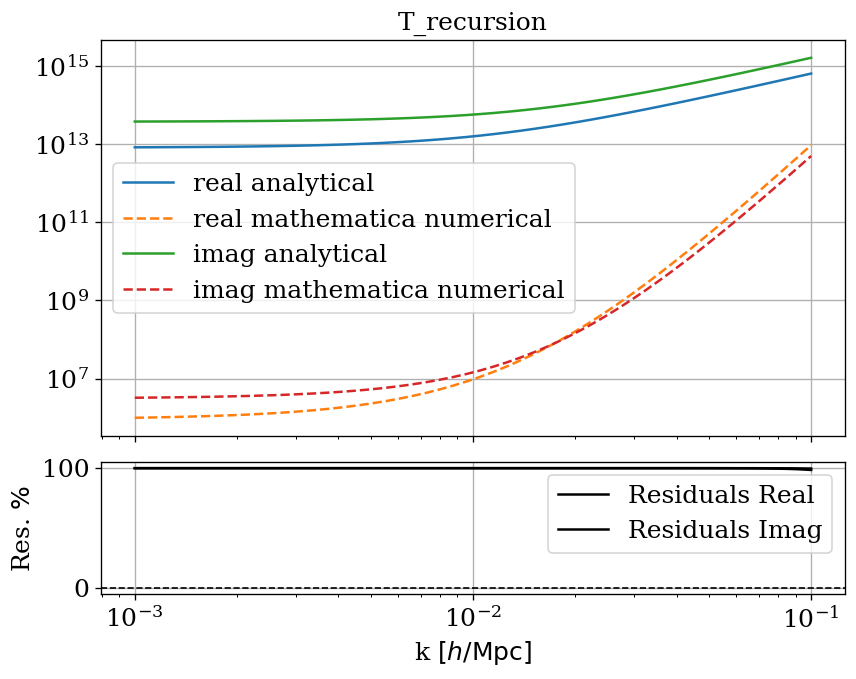

In [424]:
k_min = 1e-3
k_max = 1e-1
k_size = 50
k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)*h

M1_idx = 1
M2_idx = 3
M3_idx = 4

#d1=2, d2=2, d3=2 +
#d1=2, d2=2, d3=3 +
#d1=2, d2=3, d3=2 +
#d1=2, d2=3, d3=3 +-
#d1=3, d2=2, d3=2 +-
#d1=3, d2=2, d3=3 +-
#d1=3, d2=3, d3=2 +--
#d1=3, d2=3, d3=3 +--

d1 = -1
d2 = 3
d3 = 3

k1val = 0.01
cos12 = 0.1

Trecursion_arr = np.zeros(k_size, dtype=complex)
# Fill the array using the CLASS implementation
for idx, k2_in in enumerate(k):
    #k1val = k2_in
    k3_in_sq = k1val**2 + k2_in**2 + 2*k1val*k2_in*cos12
    Trecursion_arr[idx] = LambdaCDM.get_T_recursion(d1, d2, d3, k2_in**2, k1val**2, k3_in_sq, M_n[M1_idx], M_n[M2_idx], M_n[M3_idx])

# read Mathematica file
Trecursion_mathematica = np.array(pd.read_csv(dir+"/T_recursion_integral/T_recursion_mathematica.csv", names=["k", "Real", "Imag"]))
k_math = Trecursion_mathematica[:,0]
Trecursion_math_real = Trecursion_mathematica[:,1]
Trecursion_math_imag = Trecursion_mathematica[:,2]


x1 = k/h
x2 = k_math/h
y1real = Trecursion_arr.real + 1.e-8
y1imag = Trecursion_arr.imag + 1.e-8
y2real = Trecursion_math_real + 1.e-8
y2imag = Trecursion_math_imag + 1.e-8
ylabel = "T_recursion"


compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel)

8 8 8
2.0 2.0 2.0
2.0 2.0 3.0
2.0 3.0 2.0
2.0 3.0 3.0
3.0 2.0 2.0
3.0 2.0 3.0
3.0 3.0 2.0
3.0 3.0 3.0
factor= 1.0000000049919655 1.0000000023697395


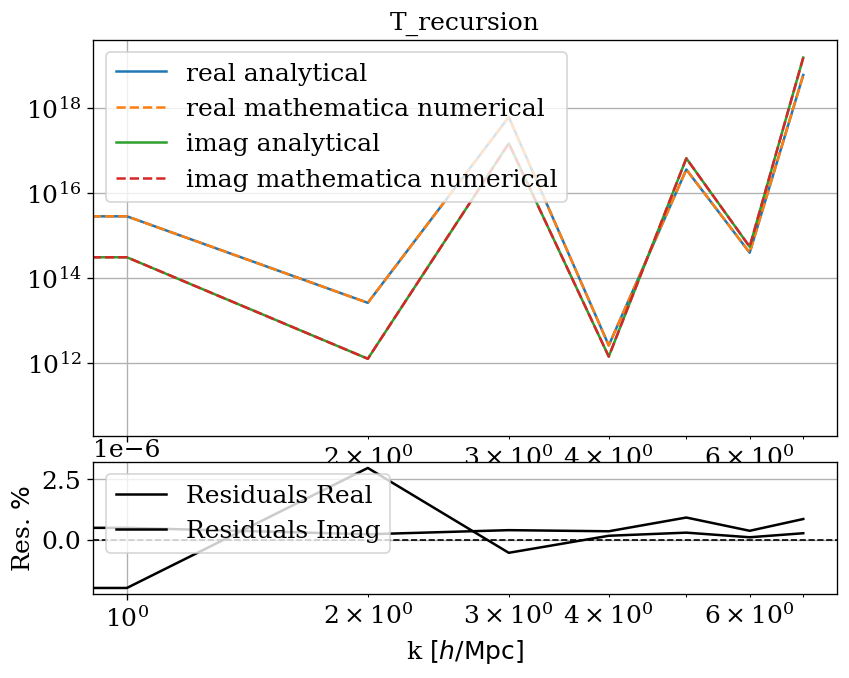

In [425]:
# read Mathematica file
T_recursion_mathematica = np.array(pd.read_csv(dir+"/T_recursion_integral/T_recursion_mathematica_mutliindex.csv", names=["M1", "M2", "M3", "k1", "k2", "k3", "d1", "d2", "d3", "Real", "Imag"]))

M1_arr = T_recursion_mathematica[:,0]
M2_arr = T_recursion_mathematica[:,1]
M3_arr = T_recursion_mathematica[:,2]
k1_math = T_recursion_mathematica[:,3]
k2_math = T_recursion_mathematica[:,4]
k3_math = T_recursion_mathematica[:,5]
d1_math = T_recursion_mathematica[:,6]
d2_math = T_recursion_mathematica[:,7]
d3_math = T_recursion_mathematica[:,8]
T_recursion_math_real = T_recursion_mathematica[:,9]
T_recursion_math_imag = T_recursion_mathematica[:,10]
if isinstance(T_math_imag[0], str):
    for idx, temp in enumerate(T_math_imag):
        T_math_imag[idx] =  eval(temp.replace("*^", "**"))


k_len = len(k1_math)


T_recursion_arr = np.zeros(k_len, dtype=complex)
x = np.arange(k_len)

for idx in range(k_len):
    d1 = d1_math[idx]
    d2 = d2_math[idx]
    d3 = d3_math[idx]
    k1_in = k1_math[idx]
    k2_in = k2_math[idx]
    k3_in = k3_math[idx]
    M1_idx = int(M1_arr[idx])
    M2_idx = int(M2_arr[idx])
    M3_idx = int(M3_arr[idx])
    #print(d1, d2, d3, k1_in, k2_in, k3_in, M1_idx, M2_idx, M3_idx)
    T_recursion_arr[idx] = LambdaCDM.get_T_recursion(d1, d2, d3, k1_in**2, k2_in**2, k3_in**2, M_n[M1_idx], M_n[M2_idx], M_n[M3_idx])


#x1 = k/h
x2 = k_math/h
y1real = T_recursion_arr.real + 1.e-8
y1imag = T_recursion_arr.imag + 1.e-8
y2real = T_recursion_math_real + 1.e-8
y2imag = T_recursion_math_imag + 1.e-8
ylabel = "T_recursion"

y1real = np.array(y1real)
y1imag = np.array(y1imag)
y2real = np.array(y2real)
y2imag = np.array(y2imag)
ylabel = np.array(ylabel)

cut = 1.

mask_real = np.abs(y1real/y2real-1) < 10.
mask_imag = np.abs(y1imag/y2imag-1) < 10.
#mask = (M1_arr == 0) & (M2_arr == 0) & (M3_arr == 0)
mask = mask_real

print(np.sum(mask_real),np.sum(mask_imag),k_len)
for i in range(np.sum(mask)):
    print(d1_math[mask][i], d2_math[mask][i], d3_math[mask][i])

compare_integrals(x[mask_real], x[mask_real], y1real[mask_real], y1imag[mask_real], y2real[mask_real], y2imag[mask_real], ylabel)

# B_recursion

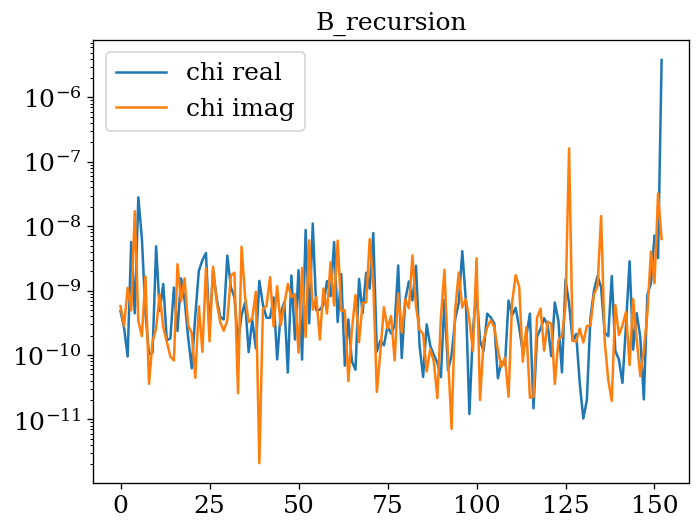

In [426]:
M1_idx = 2
M2_idx = 3
k_in = 3.14*1e-2*h

# read Mathematica file
B_recursion_mathematica = np.array(pd.read_csv(dir+"/B_recursion_integral/B_recursion_mathematica_multiindex.csv", names=["d1", "d2", "Real", "Imag"]))
n_arr = B_recursion_mathematica[:,0]
d_arr = B_recursion_mathematica[:,1]
B_recursion_math_real = B_recursion_mathematica[:,2]
B_recursion_math_imag = B_recursion_mathematica[:,3]

idx_len = len(n_arr)
B_recursion_arr = np.zeros(idx_len, dtype=complex)
for idx in range(idx_len):
    n = n_arr[idx]
    d = d_arr[idx]
    B_recursion_arr[idx] = LambdaCDM.get_B_recursion(n, d, k_in**2, M_n[M1_idx], M_n[M2_idx])


y1real = B_recursion_arr.real+1e-10
y1imag = B_recursion_arr.imag+1e-10
y2real = B_recursion_math_real+1e-10
y2imag = B_recursion_math_imag+1e-10

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)


x = np.arange(idx_len)
plt.plot(x, chi_real, label="chi real")
plt.plot(x, chi_imag, label="chi imag")
plt.yscale("log")
plt.title("B_recursion")
plt.legend()

plt.show()

# scalar_prod_one


cases that dont work: 0


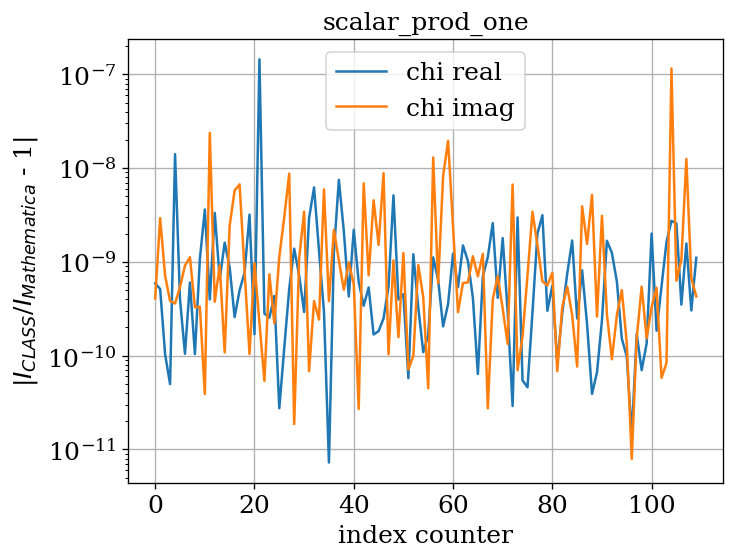

In [427]:
M1_idx = 1
M2_idx = 2

idx_sizte = 5
m_arr = [0, 1, 2, 3, 4]
n_arr = [0, 1, 2, 3, 4]
d_arr = [0, 1, 2, 3, 4]
idx_list = [1, 2, 3]
idx_track_list = []

k_in = 2.42453*1.e-2*h



# read Mathematica file
scalar_prod_one_mathematica = np.array(pd.read_csv(dir+"/scalar_prod_one_integral/scalar_prod_one_mathematica_multiindex.csv", names=["d1", "d2", "m", "n", "Real", "Imag"]))

d1_arr = scalar_prod_one_mathematica[:,0]
d2_arr = scalar_prod_one_mathematica[:,1]
n_arr = scalar_prod_one_mathematica[:,2]
m_arr = scalar_prod_one_mathematica[:,3]
scalar_prod_one_math_real = scalar_prod_one_mathematica[:,4]
scalar_prod_one_math_imag = scalar_prod_one_mathematica[:,5]



count = len(d1_arr)
scalar_prod_one_arr = np.zeros(count, dtype=complex)
for idx in range(count):
    d1 = d1_arr[idx]
    d2 = d2_arr[idx]
    m = m_arr[idx]
    n = n_arr[idx]
    #print(m, n, d1, d2)
    if d1+d2>1+n+m:
        scalar_prod_one_arr[idx] = LambdaCDM.get_scalar_prod_one(m, n, d1, d2, k_in**2, M_n[M1_idx], M_n[M2_idx])
    else:
        print("problem!!!!!")

y1real = scalar_prod_one_arr.real + 1e-10
y1imag = scalar_prod_one_arr.imag + 1e-10
y2real = scalar_prod_one_math_real + 1e-10
y2imag = scalar_prod_one_math_imag + 1e-10

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)

idx_list = []
for idx in range(count):
    d1 = int(d1_arr[idx])
    d2 = int(d2_arr[idx])
    m = int(m_arr[idx])
    n = int(n_arr[idx])
    if chi_real[idx]>1e-1 or chi_imag[idx] > 1e-1:
        idx_list.append([d1,d2,m,n])
        print(d1, d2, n, m, m+n-d1-d2)



print("\ncases that dont work:",len(idx_list))


track_idx = 6



x = np.arange(count)
plt.plot(x, np.abs(y2real/y1real-1), label="chi real")
plt.plot(x, np.abs(y2imag/y1imag-1), label="chi imag")
plt.yscale("log")
plt.ylabel(r"|$I_{CLASS}$/$I_{Mathematica}$ - 1|")
plt.xlabel("index counter")
plt.legend()
plt.grid()
plt.title("scalar_prod_one")
plt.show()



#compare_integrals(x, x, y1real, y1imag, y2real, y2imag, ylabel)





factor= 1.0000000003767953 0.9999999971117498


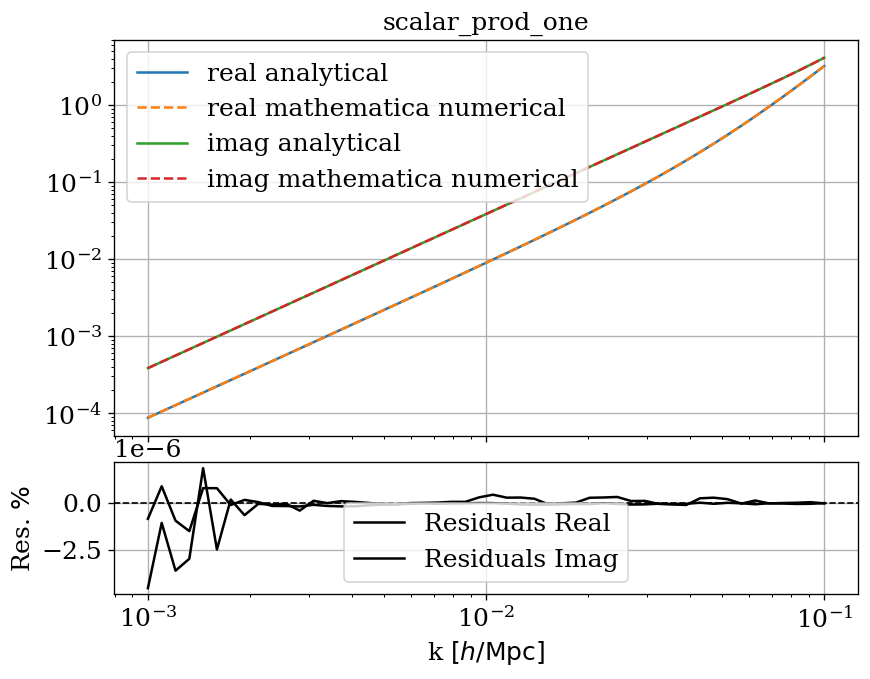

In [428]:

d1 = 2
d2 = 2
n = 0
m = 2

scalar_prod_one_arr = np.zeros(k_size, dtype=complex)
# Fill the array using the CLASS implementation
for idx, k_in in enumerate(k):
    scalar_prod_one_arr[idx] = LambdaCDM.get_scalar_prod_one(m, n, d1, d2, k_in**2, M_n[M1_idx], M_n[M2_idx])

# read Mathematica file
scalar_prod_one_mathematica = np.array(pd.read_csv(dir+"/scalar_prod_one_integral/scalar_prod_one_mathematica.csv", names=["n", "Real", "Imag"]))
k_math = scalar_prod_one_mathematica[:,0]
scalar_prod_one_math_real = scalar_prod_one_mathematica[:,1]
scalar_prod_one_math_imag = scalar_prod_one_mathematica[:,2]


x1 = k/h
x2 = k_math/h
y1real = scalar_prod_one_arr.real
y1imag = scalar_prod_one_arr.imag
y2real = scalar_prod_one_math_real
y2imag = scalar_prod_one_math_imag
ylabel = "scalar_prod_one"

compare_integrals(x1, x2, y1real, y1imag, y2real, y2imag, ylabel)

In [429]:
from scipy.special import comb


idx_val = np.arange(0, 20)

temp_list_bin = []
for n in idx_val:
        for k in idx_val:
            if n==0 and n>=k:
                temp_list_bin.append(LambdaCDM.get_util_binomial(n, k))

print(temp_list_bin)
#LambdaCDM.get_util_binomial(n, -10)
#plt.plot(temp_list_bin)

[1.0]


# tensor_red_one


cases that dont work: 0


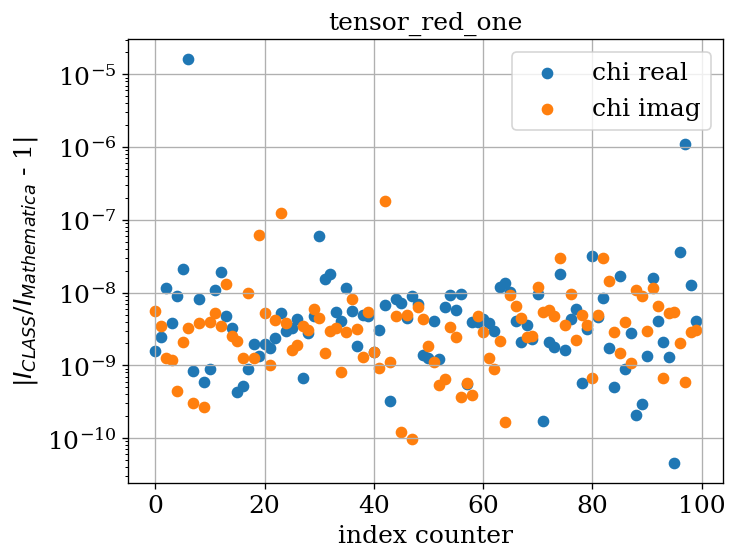

In [430]:
M1_idx = 3
M2_idx = 4

idx_track_list = []

k1_in = 1e-2*h
#k2_in = 1e-2*h
k2_in = 2.42453*1.e-2*h
cos12 = -1.# 0.314 # 1.


# read Mathematica file
tensor_red_one_mathematica = np.array(pd.read_csv(dir+"/tensor_red_one_integral/tensor_red_one_full_mathematica_multiindex.csv", names=["d1", "d2", "m", "n", "Real", "Imag"]))

d1_arr = tensor_red_one_mathematica[:,0]
d2_arr = tensor_red_one_mathematica[:,1]
n_arr = tensor_red_one_mathematica[:,2]
#m_arr = tensor_red_one_mathematica[:,3]
tensor_red_one_math_real = tensor_red_one_mathematica[:,3]
tensor_red_one_math_imag = tensor_red_one_mathematica[:,4]



count = len(d1_arr)
tensor_red_one_arr = np.zeros(count, dtype=complex)
for idx in range(count):
    d1 = d1_arr[idx]
    d2 = d2_arr[idx]
    m = m_arr[idx]
    n = n_arr[idx]

    if d1+d2>1+n:
        tensor_red_one_arr[idx] = LambdaCDM.get_tensor_red_one(n, d1, d2, k1_in**2, k2_in**2, cos12, M_n[M1_idx], M_n[M2_idx])
    else:
        print("problem!!!!!")

y1real = tensor_red_one_arr.real + 1e-10
y1imag = tensor_red_one_arr.imag + 1e-10
y2real = tensor_red_one_math_real
y2imag = tensor_red_one_math_imag

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)

idx_list = []
for idx in range(count):
    d1 = int(d1_arr[idx])
    d2 = int(d2_arr[idx])
    m = int(m_arr[idx])
    n = int(n_arr[idx])
    if chi_real[idx]>5 or chi_imag[idx] > 5:
        idx_list.append([d1,d2,m,n])
        print(d1, d2, n)



print("\ncases that dont work:",len(idx_list))


track_idx = 6



x = np.arange(count)
plt.scatter(x, np.abs(y2real/y1real-1), label="chi real")
plt.scatter(x, np.abs(y2imag/y1imag-1), label="chi imag")
plt.yscale("log")
plt.ylabel(r"|$I_{CLASS}$/$I_{Mathematica}$ - 1|")
plt.xlabel("index counter")
plt.legend()
plt.grid()
plt.title("tensor_red_one")
plt.show()

factor= 1.084411392599871 0.24936585803983508


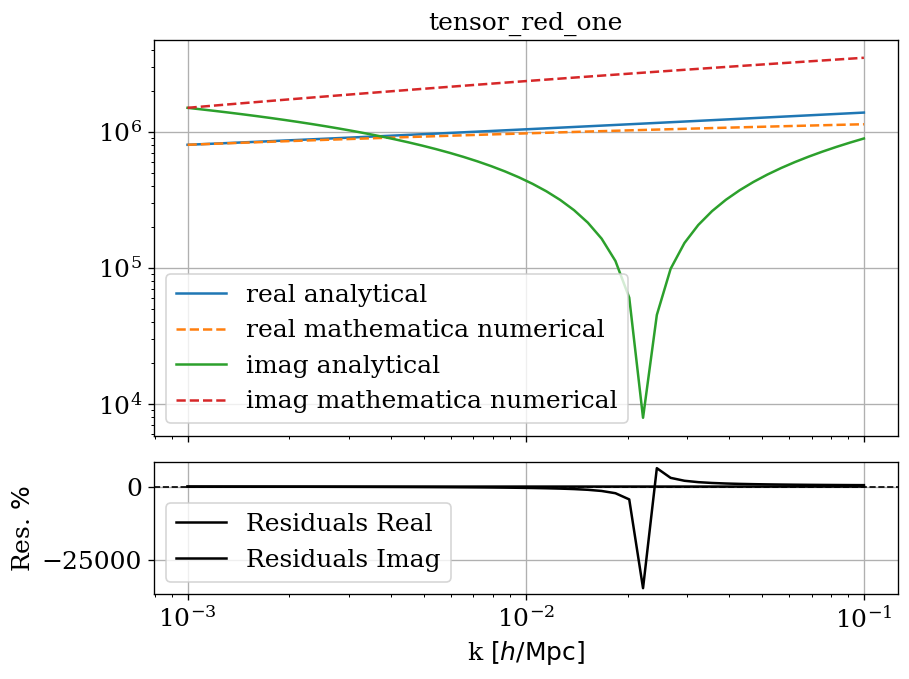

In [431]:
k_min = 1e-3*h
k_max = 1e-1*h

k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)

tensor_red_one_arr = np.zeros(k_size, dtype=complex)

M1_idx = 3
M2_idx = 4

n = 4
d1 = 3
d2 = 4


k1 = 1e-2*h


# Fill the array using the CLASS implementation
for idx, k2_in in enumerate(k):
    tensor_red_one_arr[idx] = LambdaCDM.get_tensor_red_one(n, d1, d2, k1**2, k2_in**2, cos12, M_n[M1_idx], M_n[M2_idx])

# read Mathematica file
tensor_red_one_mathematica = np.array(pd.read_csv(dir+"/tensor_red_one_integral/tensor_red_one_full_mathematica.csv", names=["k", "Real", "Imag"]))
k_math = tensor_red_one_mathematica[:,0]
tensor_red_one_math_real = tensor_red_one_mathematica[:,1]
tensor_red_one_math_imag = tensor_red_one_mathematica[:,2]

k1_in = 1e-2*h
k2_in = 2.42453*1.e-2*h
for idx, cos12_in in enumerate(k_math):
    tensor_red_one_arr[idx] = LambdaCDM.get_tensor_red_one(n, d1, d2, k1_in**2, k2_in**2, cos12_in, M_n[M1_idx], M_n[M2_idx])

x1 = k/h
x2 = k_math/h
y1real = tensor_red_one_arr.real
y1imag = tensor_red_one_arr.imag
y2real = tensor_red_one_math_real
y2imag = tensor_red_one_math_imag
ylabel = "tensor_red_one"


compare_integrals(x1, x1, y1real, y1imag, y2real, y2imag, ylabel)

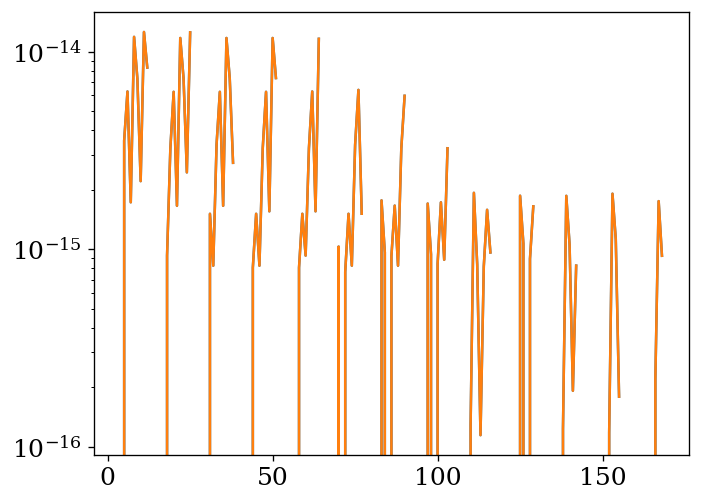

In [432]:
M = M_n[0]

def coef_dim_gen(expnum, expden):
	# function to calculate coefficient in dim_gen without using Gamma functions 
	# instead it uses a recursion relation

	# boundary conditions
	if expden == 1:
		return ((-1)**(expnum + 1))
	if expden < 1:
		return 0 
	if expden > 1:
		val = (coef_dim_gen(expnum, expden-1)*(5. - 2.*expden + 2.*expnum))/(2. - 2.*expden)
		return val


def dim_gen(expnum, expden, m):
	# calculates 3d integral of (q^2)^expnum/(q^2+m)^expden
	if m == 0.+0.*1j:
		return 0.+0.*1j
	##### no idea how coef_dim_gen works
	##### Problem: implementation using gamma function has different factor than my result. Compare Schwartz B.34
	return (2.*np.pi**2)*(coef_dim_gen(expnum,expden)*m**(expnum - expden + 1)*np.sqrt(m))


n = 2
d = 4
I_Fynn = []
I_Babis = []
idx_list = [-4,-3,-2, -1, 0, 1, 2, 3, 4, 5, 6 ,7 , 8]
counter = []
idx = 0
for n in idx_list:
	for d in idx_list:
		I_Fynn.append(LambdaCDM.get_Tad_master(n, d, M))
		I_Babis.append(dim_gen(n, d, M))
		counter.append(idx)
		idx+=1

I_Fynn = np.array(I_Fynn)+1e-10*(1+1j)
I_Babis = np.array(I_Babis)+1e-10*(1+1j)
counter = np.array(counter)

plt.plot(counter, np.abs((I_Babis.real-I_Fynn.real)/I_Fynn.real))
plt.plot(counter, np.abs((I_Babis.real-I_Fynn.real)/I_Fynn.real))
plt.yscale("log")
plt.show()




In [433]:
n=1
k=1

binomial_coeff = LambdaCDM.get_util_binomial(n, k)
print(binomial_coeff)

1.0


# tensor_red_two


cases that dont work: 0


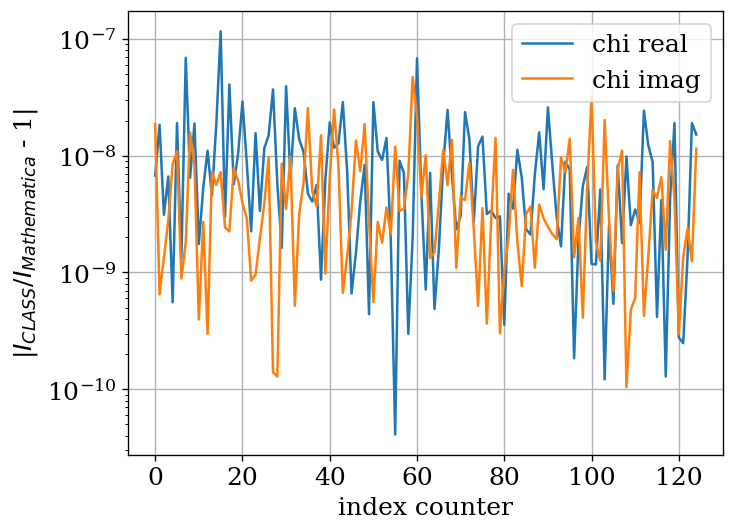

In [434]:
M_idx = 1

idx_track_list = []

k1_in = 1e-2*h
#k2_in = 1e-2*h
k2_in = 2.42453*1.e-2*h
cos12 = 0.1505438


# read Mathematica file
tensor_red_two_mathematica = np.array(pd.read_csv(dir+"/tensor_red_two_integral/tensor_red_two_mathematica_multiindex.csv", names=["d", "n1", "n2", "Real", "Imag"]))

d_arr = tensor_red_two_mathematica[:,0]
n1_arr = tensor_red_two_mathematica[:,1]
n2_arr = tensor_red_two_mathematica[:,2]

tensor_red_two_math_real = tensor_red_two_mathematica[:,3]
tensor_red_two_math_imag = tensor_red_two_mathematica[:,4]



count = len(d_arr)
tensor_red_two_arr = np.zeros(count, dtype=complex)
for idx in range(count):
    n1 = n1_arr[idx]
    n2 = n2_arr[idx]
    d = d_arr[idx]

    if d>1+n1+n2:
        tensor_red_two_arr[idx] = LambdaCDM.get_tensor_red_two(n1, n2, d, k1_in**2, k2_in**2, cos12, M_n[M_idx])
    else:
        print("problem!!!!!")

y1real = tensor_red_two_arr.real + 1e-10
y1imag = tensor_red_two_arr.imag + 1e-10
y2real = tensor_red_two_math_real
y2imag = tensor_red_two_math_imag

chi_real = np.abs(y2real/y1real-1)
chi_imag = np.abs(y2imag/y1imag-1)

idx_list = []
for idx in range(count):
    n1 = n1_arr[idx]
    n2 = n2_arr[idx]
    d = d_arr[idx]
    if chi_real[idx]>1e-1 or chi_imag[idx] > 1e-1:
        idx_list.append([n1, n2, d])
        print(n1, n2, d)



print("\ncases that dont work:",len(idx_list))


track_idx = 6



x = np.arange(count)
plt.plot(x, np.abs(y2real/y1real-1), label="chi real")
plt.plot(x, np.abs(y2imag/y1imag-1), label="chi imag")
plt.yscale("log")
plt.ylabel(r"|$I_{CLASS}$/$I_{Mathematica}$ - 1|")
plt.xlabel("index counter")
plt.legend()
plt.grid()
plt.show()

factor= 1.0000000043668154 1.0000000108804377


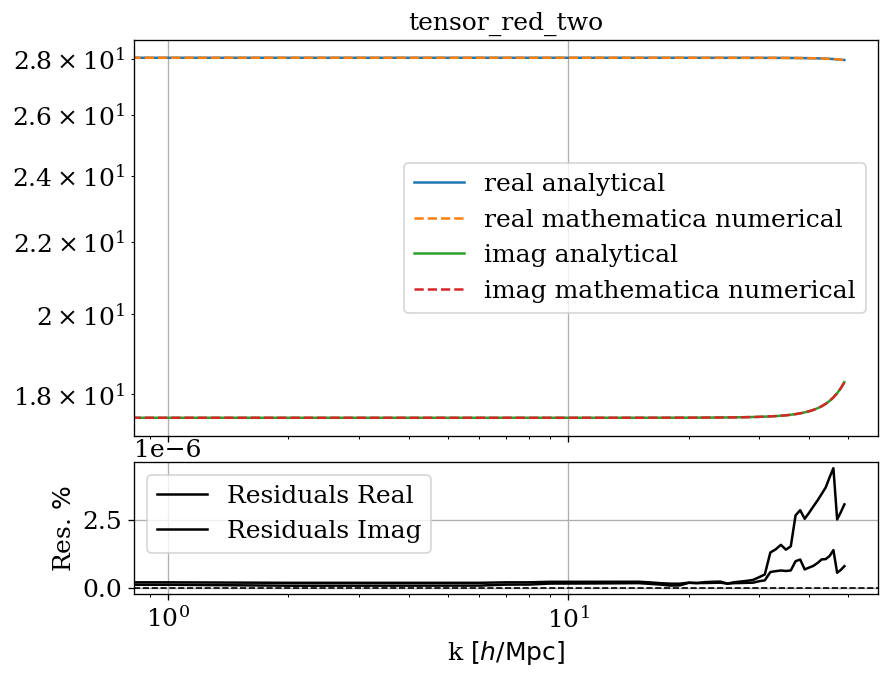

In [435]:
k_min = 1e-3*h
k_max = 1e-1*h

k = np.logspace(np.log10(k_min),np.log10(k_max), k_size)



M_idx = 1
n1 = 1
n2 = 1
d = 4

k1 = 1e-2*h
k1input = 1e-2*h



# read Mathematica file
tensor_red_two_mathematica = np.array(pd.read_csv(dir+"/tensor_red_two_integral/tensor_red_two_mathematica.csv", names=["k", "Real", "Imag"]))
k_math = tensor_red_two_mathematica[:,0]
tensor_red_two_math_real = tensor_red_two_mathematica[:,1]
tensor_red_two_math_imag = tensor_red_two_mathematica[:,2]


len_ = len(k_math)
tensor_red_two_arr = np.zeros(len_, dtype=complex)
# Fill the array using the CLASS implementation
for idx, k2 in enumerate(k_math):
    tensor_red_two_arr[idx] = LambdaCDM.get_tensor_red_two(n1, n2, d, k1input**2, k2**2, cos12, M_n[M_idx])

x = np.arange(len_)
x1 = k/h
x2 = k_math/h
y1real = tensor_red_two_arr.real
y1imag = tensor_red_two_arr.imag
y2real = tensor_red_two_math_real
y2imag = tensor_red_two_math_imag
ylabel = "tensor_red_two"


compare_integrals(x, x, y1real, y1imag, y2real, y2imag, ylabel)

In [436]:
m  = 10
n  = 1
d1 = 6
d2 = 7

print("")

list_idx_d1 = []
list_idx_d2 = []
list_d1_sum_d2 = []


B_mat = np.zeros((m+n+1, m+1),dtype=int)
idx_cache = np.zeros((m+n+1, m+1),dtype=int)
for k in range(n+1):
    for i in range(m+1):
        for j in range(m-i+1):
            d1_idx = i + k
            d2_idx = j
            d1d2 = d1+d2 - d1_idx - d2_idx
            B_mat[d1_idx][d2_idx]+=1

            if not d1_idx in list_idx_d1:
                list_idx_d1.append(d1_idx)
            if not d2_idx in list_idx_d2:
                list_idx_d2.append(d2_idx)
            if not d1d2 in list_d1_sum_d2:
                list_d1_sum_d2.append(d1d2)
            if d1d2<2:
                print(f"problem: d1={d1_idx}, d2={d2_idx}, i={i}, k={k}, j={j}")
print(list_idx_d1)
print(list_idx_d2)
print(list_d1_sum_d2)
print("\n", B_mat)


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2]

 [[1 1 1 1 1 1 1 1 1 1 1]
 [2 2 2 2 2 2 2 2 2 2 1]
 [2 2 2 2 2 2 2 2 2 1 0]
 [2 2 2 2 2 2 2 2 1 0 0]
 [2 2 2 2 2 2 2 1 0 0 0]
 [2 2 2 2 2 2 1 0 0 0 0]
 [2 2 2 2 2 1 0 0 0 0 0]
 [2 2 2 2 1 0 0 0 0 0 0]
 [2 2 2 1 0 0 0 0 0 0 0]
 [2 2 1 0 0 0 0 0 0 0 0]
 [2 1 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0]]
